# Provisional low-fraction accDM profile-likelihood analysis

This notebook combines the 1001-bin low-fraction production campaign with the targeted 2501-bin recovery campaign. The higher-resolution result is selected whenever the same coordinate exists in both campaigns. The notebook does not run CLASS, SPT, PBS jobs, or nuisance optimization. Quoted minima are always sampled grid points; interpolation is used only to draw contours.

The resulting map is provisional because it mixes momentum resolutions. The explicit overlap comparison quantifies this numerical limitation before any physical contour is interpreted.

In [13]:
from pathlib import Path
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.interpolate import RegularGridInterpolator

def find_project_root(start=Path.cwd()):
    start = start.resolve()
    for candidate in (start, *start.parents):
        if (candidate / 'pyproject.toml').is_file() and (candidate / 'lyalpha_pt').is_dir():
            return candidate
    raise FileNotFoundError('Could not locate the lyalpha_one_loop project root.')

PROJECT_ROOT = find_project_root()
SOURCE_CAMPAIGNS = [
    {
        'label': 'q1001_main',
        'directory': PROJECT_ROOT / 'runs/accdm/accdm_scan_lowf_q1001_v2',
        'momentum_bins': 1001,
        'priority': 1,
        'defines_expected_grid': True,
    },
    {
        'label': 'q2501_recovery',
        'directory': PROJECT_ROOT / 'runs/accdm/accdm_lowf_recovery_q2501_10core_v1',
        'momentum_bins': 2501,
        'priority': 2,
        'defines_expected_grid': False,
    },
]
LCDM_ONE_LOOP_CHI2 = 193.105787
ALLOWED_2D_DELTA_CHI2 = 5.991
EXCLUSION_DELTA_CHI2 = 3.841
BOUNDARY_FRACTION = 0.05
ROUGHNESS_WARNING_CHI2 = 0.5
MULTISTART_SECOND_GAP_WARNING = 0.5
SAVE_OUTPUTS = True
OUTPUT_DIR = PROJECT_ROOT / 'runs/accdm/analysis_lowf_q1001_q2501_v1'

print('Project:', PROJECT_ROOT)
for source in SOURCE_CAMPAIGNS:
    print(f"{source['label']}: {source['directory']} (q={source['momentum_bins']})")
print('Output:', OUTPUT_DIR)

Project: /home/2/ks405818/Master/lyalpha_one_loop
q1001_main: /home/2/ks405818/Master/lyalpha_one_loop/runs/accdm/accdm_scan_lowf_q1001_v2 (q=1001)
q2501_recovery: /home/2/ks405818/Master/lyalpha_one_loop/runs/accdm/accdm_lowf_recovery_q2501_10core_v1 (q=2501)
Output: /home/2/ks405818/Master/lyalpha_one_loop/runs/accdm/analysis_lowf_q1001_q2501_v1


## Load every completed fit

The main campaign defines the expected 50 by 17 grid. Recovery points are matched by rounded physical coordinates rather than by row number.

In [14]:
def active_mask(manifest):
    if 'active' not in manifest:
        return np.ones(len(manifest), dtype=bool)
    return manifest['active'].astype(str).str.lower().isin({'true', '1', 'yes'})

def coordinate_key(logm, logf):
    return f'{float(logm):.10f}|{float(logf):.10f}'

def load_campaign(source):
    directory = source['directory']
    manifest = pd.read_csv(directory / 'manifest.csv')
    manifest = manifest.loc[active_mask(manifest)].copy()
    rows = []
    nuisance_rows = []
    for record in manifest.to_dict(orient='records'):
        point_id = record['point_id']
        fit_path = directory / 'fits' / f'{point_id}.json'
        fit_done = directory / 'status/fit' / f'{point_id}.done.json'
        theory_path = directory / 'theory' / f'{point_id}.npz'
        theory_done = directory / 'status/theory' / f'{point_id}.done.json'
        key = coordinate_key(record['log10m_acc'], record['log10f_acc'])
        row = {
            **record,
            'coordinate_key': key,
            'source_label': source['label'],
            'source_directory': str(directory),
            'momentum_bins': int(source['momentum_bins']),
            'source_priority': int(source['priority']),
            'theory_complete': theory_path.is_file() and theory_done.is_file(),
            'fit_complete': fit_path.is_file() and fit_done.is_file(),
            'fit_path': str(fit_path),
            'chi2_one_loop': np.nan,
            'chi2_per_dof': np.nan,
            'optimizer_success': np.nan,
            'optimizer_message': None,
            'minimum_bound_distance': np.nan,
            'minimum_bound_parameter': None,
            'near_bound_5pct': False,
            'multistart_count': 0,
            'multistart_chi2_range': np.nan,
            'multistart_second_gap': np.nan,
            'direct_k20': False,
        }
        if fit_path.is_file():
            payload = json.loads(fit_path.read_text(encoding='utf-8'))
            fit = payload.get('fits', {}).get('one_loop')
            if fit is not None:
                row['chi2_one_loop'] = float(fit['chi2'])
                row['chi2_per_dof'] = float(fit['chi2_per_dof'])
                row['optimizer_success'] = bool(fit.get('optimizer_success', False))
                row['optimizer_message'] = fit.get('optimizer_message')
                row['direct_k20'] = (
                    np.isclose(float(fit.get('k_uv_cut_hmpc', np.nan)), 20.0)
                    and not bool(payload.get('cutoff_continuation_enabled', True))
                )
                multistart = np.sort(np.asarray(fit.get('multistart_chi2', []), dtype=float))
                multistart = multistart[np.isfinite(multistart)]
                row['multistart_count'] = int(multistart.size)
                if multistart.size:
                    row['multistart_chi2_range'] = float(multistart[-1] - multistart[0])
                if multistart.size >= 2:
                    row['multistart_second_gap'] = float(multistart[1] - multistart[0])
                diagnostics = fit.get('boundary_diagnostics', [])
                if diagnostics:
                    nearest = min(
                        diagnostics,
                        key=lambda item: float(item['relative_distance_to_nearest_bound']),
                    )
                    row['minimum_bound_distance'] = float(nearest['relative_distance_to_nearest_bound'])
                    row['minimum_bound_parameter'] = nearest['parameter']
                    row['near_bound_5pct'] = row['minimum_bound_distance'] <= BOUNDARY_FRACTION
                for name, value in fit.get('parameters', {}).items():
                    row[f'parameter_{name}'] = float(value)
                for item in diagnostics:
                    nuisance_rows.append({
                        'coordinate_key': key,
                        'point_id': point_id,
                        'source_label': source['label'],
                        'momentum_bins': int(source['momentum_bins']),
                        'log10m_acc': float(record['log10m_acc']),
                        'log10f_acc': float(record['log10f_acc']),
                        'parameter': item['parameter'],
                        'value': float(item['value']),
                        'lower': float(item['lower']),
                        'upper': float(item['upper']),
                        'relative_distance_to_nearest_bound': float(item['relative_distance_to_nearest_bound']),
                        'within_5pct': float(item['relative_distance_to_nearest_bound']) <= BOUNDARY_FRACTION,
                    })
        rows.append(row)
    return manifest, pd.DataFrame(rows), pd.DataFrame(nuisance_rows)

loaded = [load_campaign(source) for source in SOURCE_CAMPAIGNS]
manifests = {source['label']: item[0] for source, item in zip(SOURCE_CAMPAIGNS, loaded)}
all_results = pd.concat([item[1] for item in loaded], ignore_index=True, sort=False)
all_nuisance = pd.concat([item[2] for item in loaded], ignore_index=True, sort=False)
display(all_results.groupby('source_label').agg(
    manifest_points=('point_id', 'size'),
    theory_complete=('theory_complete', 'sum'),
    fit_complete=('fit_complete', 'sum'),
    fitted_points=('chi2_one_loop', 'count'),
))

,manifest_points,theory_complete,fit_complete,fitted_points
source_label,,,,
q1001_main,850,843,843,843
q2501_recovery,8,8,8,8


## Merge policy, completeness, and resolution overlaps

Among available fits, the largest momentum grid wins at a duplicated coordinate. No missing coordinate is silently interpolated.

In [15]:
main_source = next(source for source in SOURCE_CAMPAIGNS if source['defines_expected_grid'])
expected_manifest = manifests[main_source['label']].copy()
expected_manifest['coordinate_key'] = [
    coordinate_key(logm, logf)
    for logm, logf in zip(expected_manifest['log10m_acc'], expected_manifest['log10f_acc'])
]
expected = expected_manifest[[
    'coordinate_key', 'point_id', 'log10m_acc', 'log10f_acc'
]].rename(columns={'point_id': 'expected_point_id'})

available = all_results.dropna(subset=['chi2_one_loop']).copy()
selected = (
    available.sort_values(['coordinate_key', 'momentum_bins', 'source_priority'])
    .drop_duplicates('coordinate_key', keep='last')
)
merged = expected.merge(
    selected.drop(columns=['log10m_acc', 'log10f_acc']),
    on='coordinate_key', how='left', validate='one_to_one',
)
merged['point_id'] = merged['expected_point_id']
missing = merged[merged['chi2_one_loop'].isna()].copy()

selected_sources = merged[['coordinate_key', 'source_label', 'momentum_bins']]
nuisance = all_nuisance.merge(
    selected_sources,
    on=['coordinate_key', 'source_label', 'momentum_bins'],
    how='inner',
)

duplicate_counts = available.groupby('coordinate_key').size()
duplicate_keys = duplicate_counts[duplicate_counts > 1].index
duplicate_rows = available[available['coordinate_key'].isin(duplicate_keys)].copy()
overlap_chi2 = duplicate_rows.pivot_table(
    index=['coordinate_key', 'log10m_acc', 'log10f_acc'],
    columns='momentum_bins', values='chi2_one_loop', aggfunc='min',
).reset_index()
if 1001 in overlap_chi2 and 2501 in overlap_chi2:
    overlap_chi2['delta_chi2_q2501_minus_q1001'] = overlap_chi2[2501] - overlap_chi2[1001]

status = pd.Series({
    'expected grid points': len(expected),
    'selected fitted points': int(merged['chi2_one_loop'].notna().sum()),
    'missing points': len(missing),
    'selected q=1001': int((merged['momentum_bins'] == 1001).sum()),
    'selected q=2501': int((merged['momentum_bins'] == 2501).sum()),
    'coordinates fitted at multiple q': len(overlap_chi2),
})
display(status.to_frame('count'))
display(missing[['expected_point_id', 'log10m_acc', 'log10f_acc']])
display(overlap_chi2)

,count
expected grid points,850
selected fitted points,850
missing points,0
selected q=1001,842
selected q=2501,8
coordinates fitted at multiple q,1


,expected_point_id,log10m_acc,log10f_acc


momentum_bins,coordinate_key,log10m_acc,log10f_acc,1001,2501,delta_chi2_q2501_minus_q1001
0,12.0000000000|-1.0000000000,12.0,-1.0,194.765288,192.393479,-2.371809


## Sampled low-fraction minimum and LCDM-like edge

This is only the minimum of the low-fraction slice. A minimum at `log10f_acc=-1` lies on the interface with the still-running high-fraction campaign and is not a global accDM minimum. The `log10f_acc=-4` edge should be nearly independent of mass and therefore provides a useful combined theory-plus-fit stability check.

In [16]:
if not missing.empty:
    raise RuntimeError(
        f'The merged grid is incomplete ({len(missing)} missing points). '
        'Inspect the table above before drawing a regular-grid map.'
    )

completed = merged.copy()
completed['delta_chi2_from_lowf_minimum'] = (
    completed['chi2_one_loop'] - completed['chi2_one_loop'].min()
)
completed['delta_chi2_vs_lcdm'] = completed['chi2_one_loop'] - LCDM_ONE_LOOP_CHI2
completed['inside_lowf_95pct'] = (
    completed['delta_chi2_from_lowf_minimum'] <= ALLOWED_2D_DELTA_CHI2
)
best = completed.loc[completed['chi2_one_loop'].idxmin()]
upper_fraction_edge = float(completed['log10f_acc'].max())
best_on_highf_interface = np.isclose(best['log10f_acc'], upper_fraction_edge)

edge_logf = float(completed['log10f_acc'].min())
lcdm_like_edge = completed[np.isclose(completed['log10f_acc'], edge_logf)].sort_values('log10m_acc')
edge_spread = float(lcdm_like_edge['chi2_one_loop'].max() - lcdm_like_edge['chi2_one_loop'].min())

columns = [
    'point_id', 'log10m_acc', 'log10f_acc', 'momentum_bins',
    'chi2_one_loop', 'delta_chi2_from_lowf_minimum', 'delta_chi2_vs_lcdm',
    'minimum_bound_parameter', 'minimum_bound_distance',
    'optimizer_success', 'multistart_second_gap',
]
display(completed.nsmallest(20, 'chi2_one_loop')[columns])
print(f"Low-fraction sampled minimum: {best['point_id']}")
print(f"  log10(m_acc/GeV) = {best['log10m_acc']:.9g}")
print(f"  log10(f_acc)     = {best['log10f_acc']:.9g}")
print(f"  f_acc            = {10**best['log10f_acc']:.9g}")
print(f"  chi2              = {best['chi2_one_loop']:.9f}")
print(f"  Delta chi2 vs LCDM reference = {best['delta_chi2_vs_lcdm']:+.9f}")
print('  On high-fraction interface:', best_on_highf_interface)
print(f'LCDM-like edge log10(f_acc)={edge_logf:g}: chi2 spread={edge_spread:.6f}')

,point_id,log10m_acc,log10f_acc,momentum_bins,chi2_one_loop,delta_chi2_from_lowf_minimum,delta_chi2_vs_lcdm,minimum_bound_parameter,minimum_bound_distance,optimizer_success,multistart_second_gap
573,accdm_logm15p7142857142857_logfm1p3,15.714286,-1.300,1001,188.986413,0.000000,-4.119374,beta_ct,0.267960,True,0.000000e+00
574,accdm_logm15p7142857142857_logfm1p225,15.714286,-1.225,1001,189.033078,0.046666,-4.072709,beta_ct,0.260682,True,0.000000e+00
590,accdm_logm15p8571428571429_logfm1p3,15.857143,-1.300,1001,189.166786,0.180373,-3.939001,beta_ct,0.260778,True,0.000000e+00
572,accdm_logm15p7142857142857_logfm1p375,15.714286,-1.375,1001,189.171168,0.184756,-3.934619,beta_ct,0.273742,True,0.000000e+00
591,accdm_logm15p8571428571429_logfm1p225,15.857143,-1.225,1001,189.247865,0.261452,-3.857922,beta_ct,0.251597,True,0.000000e+00
589,accdm_logm15p8571428571429_logfm1p375,15.857143,-1.375,1001,189.322341,0.335928,-3.783446,beta_ct,0.267982,True,0.000000e+00
356,accdm_logm13p8571428571429_logfm1,13.857143,-1.000,1001,189.446102,0.459689,-3.659685,beta_ct,0.230014,True,0.000000e+00
571,accdm_logm15p7142857142857_logfm1p45,15.714286,-1.450,1001,189.478411,0.491998,-3.627376,alpha_bias,0.290250,True,1.136868e-13
575,accdm_logm15p7142857142857_logfm1p15,15.714286,-1.150,1001,189.484784,0.498371,-3.621003,alpha_bias,0.284967,True,5.684342e-14
588,accdm_logm15p8571428571429_logfm1p45,15.857143,-1.450,1001,189.604876,0.618463,-3.500911,beta_ct,0.273734,True,0.000000e+00


Low-fraction sampled minimum: accdm_logm15p7142857142857_logfm1p3
  log10(m_acc/GeV) = 15.7142857
  log10(f_acc)     = -1.3
  f_acc            = 0.0501187234
  chi2              = 188.986412635
  Delta chi2 vs LCDM reference = -4.119374365
  On high-fraction interface: False
LCDM-like edge log10(f_acc)=-4: chi2 spread=0.015846


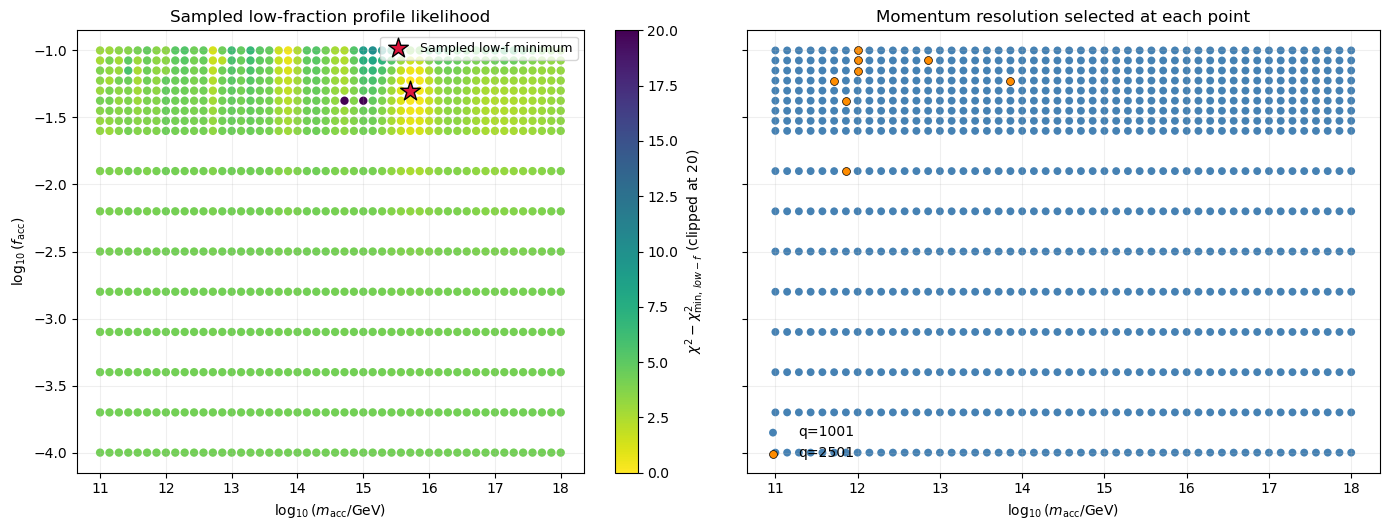

In [17]:
fig_sampled, axes = plt.subplots(1, 2, figsize=(14.0, 5.4), sharex=True, sharey=True)
scatter = axes[0].scatter(
    completed['log10m_acc'], completed['log10f_acc'],
    c=np.clip(completed['delta_chi2_from_lowf_minimum'], 0, 20),
    cmap='viridis_r', s=36, edgecolor='none', rasterized=True,
)
fig_sampled.colorbar(scatter, ax=axes[0], label=r'$\chi^2-\chi^2_{\min,\,low-f}$ (clipped at 20)')
axes[0].scatter(
    [best['log10m_acc']], [best['log10f_acc']], marker='*', s=220,
    color='crimson', edgecolor='black', label='Sampled low-f minimum', zorder=6,
)
axes[0].set_title('Sampled low-fraction profile likelihood')
axes[0].legend(frameon=True, fontsize=9)

source_colors = {1001: 'steelblue', 2501: 'darkorange'}
for q, group in completed.groupby('momentum_bins'):
    axes[1].scatter(
        group['log10m_acc'], group['log10f_acc'], s=32,
        color=source_colors.get(int(q), 'gray'), label=f'q={int(q)}',
        edgecolor='black' if int(q) > 1001 else 'none', linewidth=0.5,
    )
axes[1].set_title('Momentum resolution selected at each point')
axes[1].legend(frameon=False)
for ax in axes:
    ax.set_xlabel(r'$\log_{10}(m_{\rm acc}/\mathrm{GeV})$')
    ax.grid(alpha=0.2)
axes[0].set_ylabel(r'$\log_{10}(f_{\rm acc})$')
fig_sampled.tight_layout()
plt.show()

## Paper-style profile-likelihood maps

The left panel is conditional on the analyzed low-fraction slice. The right panel uses the stated LCDM reference. The high-fraction side of either contour cannot be finalized until the 5001-bin campaign is merged.

In [18]:
x_grid = np.sort(completed['log10m_acc'].unique())
y_grid = np.sort(completed['log10f_acc'].unique())

def regular_grid(column):
    table = completed.pivot(
        index='log10f_acc', columns='log10m_acc', values=column
    ).reindex(index=y_grid, columns=x_grid)
    values = table.to_numpy(dtype=float)
    if values.shape != (len(y_grid), len(x_grid)) or not np.isfinite(values).all():
        raise RuntimeError(
            f'Incomplete regular grid for {column}: shape={values.shape}, '
            f'missing={np.isnan(values).sum()}.'
        )
    return values

def interpolate_surface(values, nx=560, ny=420):
    x_dense = np.linspace(x_grid.min(), x_grid.max(), nx)
    y_dense = np.linspace(y_grid.min(), y_grid.max(), ny)
    xx, yy = np.meshgrid(x_dense, y_dense)
    interpolator = RegularGridInterpolator(
        (y_grid, x_grid), values, method='linear', bounds_error=False
    )
    zz = interpolator(np.column_stack([yy.ravel(), xx.ravel()])).reshape(xx.shape)
    return x_dense, y_dense, zz

grid_delta_min = regular_grid('delta_chi2_from_lowf_minimum')
grid_delta_lcdm = regular_grid('delta_chi2_vs_lcdm')
x_dense, y_dense, delta_min_dense = interpolate_surface(grid_delta_min)
_, _, delta_lcdm_dense = interpolate_surface(grid_delta_lcdm)
print(f'Grid shape: {len(x_grid)} x {len(y_grid)} = {grid_delta_min.size}')

Grid shape: 50 x 17 = 850


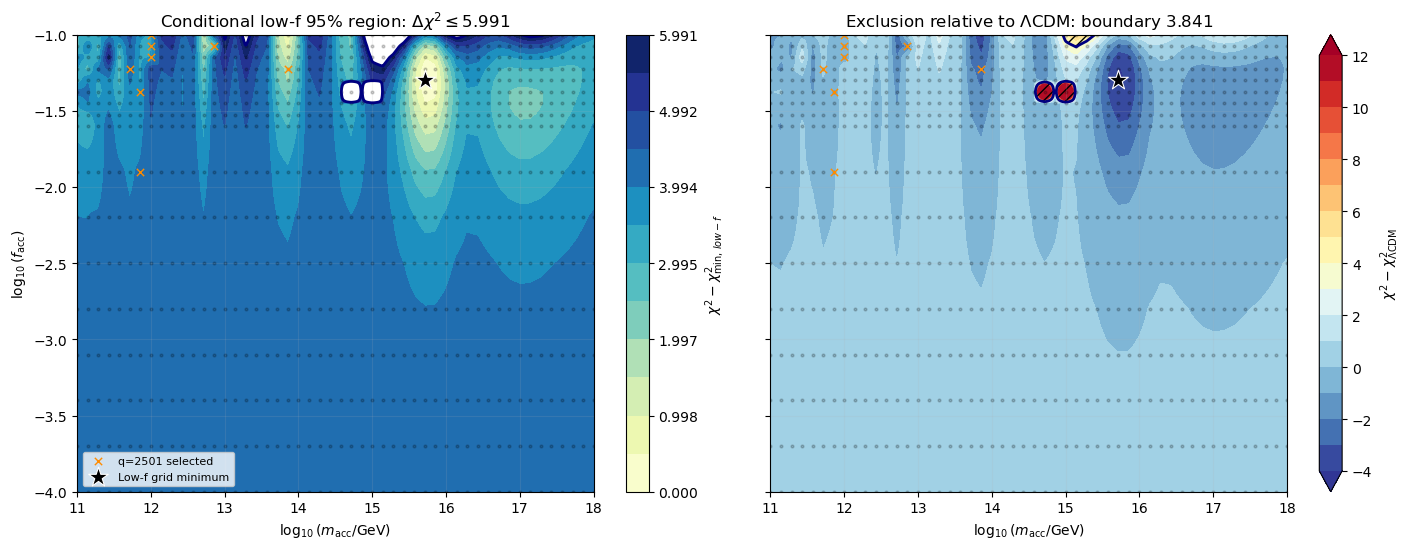

In [19]:
fig_maps, axes = plt.subplots(1, 2, figsize=(14.4, 5.6), sharex=True, sharey=True)
allowed_display = np.ma.masked_where(
    delta_min_dense > ALLOWED_2D_DELTA_CHI2, delta_min_dense
)
filled_allowed = axes[0].contourf(
    x_dense, y_dense, allowed_display,
    levels=np.linspace(0, ALLOWED_2D_DELTA_CHI2, 13), cmap='YlGnBu',
)
axes[0].contour(
    x_dense, y_dense, delta_min_dense,
    levels=[ALLOWED_2D_DELTA_CHI2], colors='navy', linewidths=2,
)
fig_maps.colorbar(filled_allowed, ax=axes[0], label=r'$\chi^2-\chi^2_{\min,\,low-f}$')
axes[0].set_title(r'Conditional low-f 95% region: $\Delta\chi^2\leq5.991$')

lcdm_display = np.clip(delta_lcdm_dense, -4, 12)
filled_lcdm = axes[1].contourf(
    x_dense, y_dense, lcdm_display, levels=np.linspace(-4, 12, 17),
    cmap='RdYlBu_r', extend='both',
)
axes[1].contour(
    x_dense, y_dense, delta_lcdm_dense,
    levels=[EXCLUSION_DELTA_CHI2], colors='navy', linewidths=2,
)
axes[1].contourf(
    x_dense, y_dense, delta_lcdm_dense,
    levels=[EXCLUSION_DELTA_CHI2, np.nanmax(delta_lcdm_dense) + 1],
    colors='none', hatches=['///'],
)
fig_maps.colorbar(filled_lcdm, ax=axes[1], label=r'$\chi^2-\chi^2_{\Lambda\mathrm{CDM}}$')
axes[1].set_title(r'Exclusion relative to $\Lambda$CDM: boundary 3.841')

for ax in axes:
    ax.scatter(
        completed['log10m_acc'], completed['log10f_acc'],
        s=4, color='black', alpha=0.18, rasterized=True,
    )
    recovery = completed[completed['momentum_bins'] > 1001]
    ax.scatter(
        recovery['log10m_acc'], recovery['log10f_acc'],
        marker='x', s=28, color='darkorange', linewidth=1.0, label='q=2501 selected',
    )
    ax.scatter(
        [best['log10m_acc']], [best['log10f_acc']], marker='*', s=220,
        color='black', edgecolor='white', linewidth=0.8, label='Low-f grid minimum', zorder=6,
    )
    ax.set_xlabel(r'$\log_{10}(m_{\rm acc}/\mathrm{GeV})$')
    ax.grid(alpha=0.15)
axes[0].set_ylabel(r'$\log_{10}(f_{\rm acc})$')
axes[0].legend(frameon=True, fontsize=8, loc='best')
fig_maps.tight_layout()
plt.show()

## Momentum-resolution and LCDM-edge diagnostics

A non-negligible q=1001 to q=2501 shift at the overlap coordinate is a theory-resolution uncertainty, not an optimizer uncertainty. The mass dependence along the smallest-fraction edge tests both numerical theory stability and independent-fit consistency.

momentum_bins,coordinate_key,log10m_acc,log10f_acc,1001,2501,delta_chi2_q2501_minus_q1001
0,12.0000000000|-1.0000000000,12.0,-1.0,194.765288,192.393479,-2.371809


Maximum available |Delta chi2| between q=1001 and q=2501: 2.371809


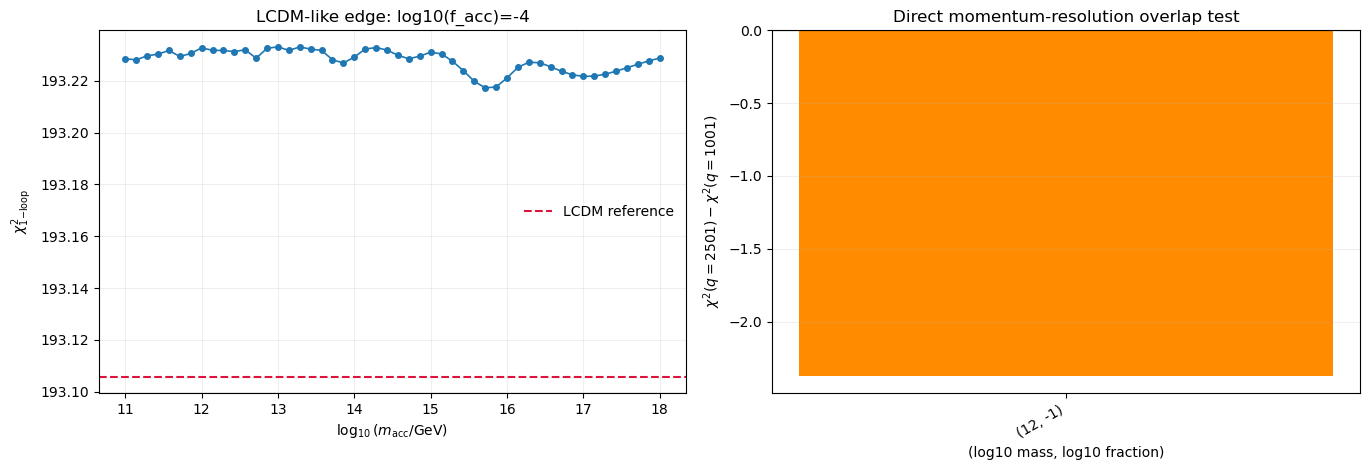

In [20]:
display(overlap_chi2)
if 'delta_chi2_q2501_minus_q1001' in overlap_chi2:
    maximum_overlap_shift = float(overlap_chi2['delta_chi2_q2501_minus_q1001'].abs().max())
else:
    maximum_overlap_shift = np.nan
print(f'Maximum available |Delta chi2| between q=1001 and q=2501: {maximum_overlap_shift:.6f}')

fig_edge, axes = plt.subplots(1, 2, figsize=(13.8, 4.8))
axes[0].plot(
    lcdm_like_edge['log10m_acc'], lcdm_like_edge['chi2_one_loop'],
    marker='o', ms=4, lw=1.2,
)
axes[0].axhline(LCDM_ONE_LOOP_CHI2, color='crimson', ls='--', label='LCDM reference')
axes[0].set_title(f'LCDM-like edge: log10(f_acc)={edge_logf:g}')
axes[0].set_xlabel(r'$\log_{10}(m_{\rm acc}/\mathrm{GeV})$')
axes[0].set_ylabel(r'$\chi^2_{1\mathrm{-loop}}$')
axes[0].legend(frameon=False)
axes[0].grid(alpha=0.2)

if not overlap_chi2.empty and 1001 in overlap_chi2 and 2501 in overlap_chi2:
    labels = [f"({row.log10m_acc:g}, {row.log10f_acc:g})" for row in overlap_chi2.itertuples()]
    shifts = overlap_chi2['delta_chi2_q2501_minus_q1001']
    axes[1].bar(np.arange(len(shifts)), shifts, color='darkorange')
    axes[1].set_xticks(np.arange(len(shifts)), labels, rotation=30, ha='right')
axes[1].axhline(0, color='black', lw=0.8)
axes[1].set_title('Direct momentum-resolution overlap test')
axes[1].set_xlabel('(log10 mass, log10 fraction)')
axes[1].set_ylabel(r'$\chi^2(q=2501)-\chi^2(q=1001)$')
axes[1].grid(axis='y', alpha=0.2)
fig_edge.tight_layout()
plt.show()

## Nuisance parameters and five-percent boundary audit

The saved `near_bound` flag uses a one-percent threshold. This notebook applies the requested five-percent threshold. Warnings inside the conditional low-f 95% region receive the highest priority.

In [21]:
best_fit_path = Path(best['fit_path'])
best_payload = json.loads(best_fit_path.read_text(encoding='utf-8'))
best_record = best_payload['fits']['one_loop']
best_boundaries = pd.DataFrame(best_record.get('boundary_diagnostics', []))
best_boundaries['distance_percent'] = 100 * best_boundaries['relative_distance_to_nearest_bound']
best_boundaries['within_5pct'] = (
    best_boundaries['relative_distance_to_nearest_bound'] <= BOUNDARY_FRACTION
)
display(best_boundaries[[
    'parameter', 'value', 'lower', 'upper', 'distance_percent', 'near_bound', 'within_5pct'
]].sort_values('distance_percent'))
print('Optimizer success:', best_record.get('optimizer_success'))
print('Optimizer message:', best_record.get('optimizer_message'))
print('Multistart chi2:', best_record.get('multistart_chi2', []))
print('Fit stages:', best_record.get('fit_stages', []))

likelihood = completed[[
    'coordinate_key', 'point_id', 'chi2_one_loop',
    'delta_chi2_from_lowf_minimum', 'inside_lowf_95pct',
]]
nuisance_audit = nuisance.merge(likelihood, on='coordinate_key', how='left', suffixes=('', '_selected'))
boundary_summary = nuisance_audit.groupby('parameter').agg(
    grid_points=('coordinate_key', 'nunique'),
    points_within_5pct=('within_5pct', 'sum'),
    minimum_distance=('relative_distance_to_nearest_bound', 'min'),
    median_distance=('relative_distance_to_nearest_bound', 'median'),
).sort_values('minimum_distance')
allowed_warnings = nuisance_audit[
    nuisance_audit['inside_lowf_95pct'] & nuisance_audit['within_5pct']
].sort_values(['relative_distance_to_nearest_bound', 'chi2_one_loop'])
display(boundary_summary)
print('Five-percent warnings inside the conditional low-f 95% region:', len(allowed_warnings))
display(allowed_warnings[[
    'point_id_selected', 'log10m_acc', 'log10f_acc', 'momentum_bins',
    'parameter', 'value', 'lower', 'upper',
    'relative_distance_to_nearest_bound', 'delta_chi2_from_lowf_minimum',
]].head(60))

,parameter,value,lower,upper,distance_percent,near_bound,within_5pct
5,beta_ct,46.407997,-100.000000,100.000000,26.796001,False,False
2,alpha_bias,-3.391419,-8.000000,8.000000,28.803630,False,False
0,log_alpha_F,-4.515808,-11.512925,0.693147,42.675111,False,False
3,beta_bias,1.383939,-15.000000,20.000000,46.811256,False,False
1,beta_F,4.914918,-10.000000,20.000000,49.716394,False,False
4,alpha_ct,-0.043298,-100.000000,100.000000,49.978351,False,False


Optimizer success: True
Optimizer message: profiled amplitudes; selected beta_ct_upper_de_nelder-mead
Multistart chi2: [231.30103752458552, 188.98641263541182, 225.2221666307635, 188.98641263541168, 188.98641263541185, 231.30103752458552, 188.98641263541182, 225.1850423453751, 188.98641263541168, 188.98641263541177]
Fit stages: [{'chi2': 188.98641263541168, 'stage': 'base'}, {'chi2': 188.98641263541168, 'stage': 'expanded'}]


,grid_points,points_within_5pct,minimum_distance,median_distance
parameter,,,,
beta_ct,850,2,0.013681,0.299472
alpha_bias,850,0,0.272703,0.294679
log_alpha_F,850,0,0.404539,0.433103
beta_bias,850,0,0.457842,0.469093
beta_F,850,0,0.475538,0.495662
alpha_ct,850,0,0.499767,0.499788


Five-percent warnings inside the conditional low-f 95% region: 2


,point_id_selected,log10m_acc,log10f_acc,momentum_bins,parameter,value,lower,upper,relative_distance_to_nearest_bound,delta_chi2_from_lowf_minimum
4133,accdm_logm16p7142857142857_logfm1,16.714286,-1.000,1001,beta_ct,97.263781,-100.0,100.0,0.013681,4.870990
4829,accdm_logm17p7142857142857_logfm1p225,17.714286,-1.225,1001,beta_ct,93.459421,-100.0,100.0,0.032703,2.907257


## Fit-stability diagnostics and targeted refit candidates

The current fits are safer than the first DCDM pass: they are direct kUV=20 fits with five global seeds, profiled amplitudes, explicit beta-ct face searches, and staged counterterm expansion. They are not mathematically guaranteed to find the same basin at every one of 850 independent grid points. A large isolated likelihood residual, a single uniquely successful multistart basin, an optimizer warning, or a nuisance-bound warning marks a point for targeted neighbor-seeded refitting.

In [22]:
chi2_grid = regular_grid('chi2_one_loop')
roughness_grid = np.full_like(chi2_grid, np.nan, dtype=float)
for iy, y in enumerate(y_grid):
    for ix, x in enumerate(x_grid):
        predictions = []
        if 0 < ix < len(x_grid) - 1:
            predictions.append(np.interp(
                x, [x_grid[ix - 1], x_grid[ix + 1]],
                [chi2_grid[iy, ix - 1], chi2_grid[iy, ix + 1]],
            ))
        if 0 < iy < len(y_grid) - 1:
            predictions.append(np.interp(
                y, [y_grid[iy - 1], y_grid[iy + 1]],
                [chi2_grid[iy - 1, ix], chi2_grid[iy + 1, ix]],
            ))
        if predictions:
            roughness_grid[iy, ix] = chi2_grid[iy, ix] - np.mean(predictions)

roughness_table = pd.DataFrame(roughness_grid, index=y_grid, columns=x_grid)
completed['local_chi2_roughness'] = [
    roughness_table.loc[logf, logm]
    for logm, logf in zip(completed['log10m_acc'], completed['log10f_acc'])
]

def refit_reasons(row):
    reasons = []
    if not bool(row['direct_k20']):
        reasons.append('not_direct_k20')
    if not bool(row['optimizer_success']):
        reasons.append('optimizer_warning')
    if bool(row['near_bound_5pct']):
        reasons.append('nuisance_within_5pct')
    if np.isfinite(row['local_chi2_roughness']) and abs(row['local_chi2_roughness']) > ROUGHNESS_WARNING_CHI2:
        reasons.append('local_likelihood_roughness')
    if np.isfinite(row['multistart_second_gap']) and row['multistart_second_gap'] > MULTISTART_SECOND_GAP_WARNING:
        reasons.append('isolated_multistart_minimum')
    return ';'.join(reasons)

completed['refit_reasons'] = completed.apply(refit_reasons, axis=1)
refit_candidates = completed[completed['refit_reasons'] != ''].copy()
refit_candidates['priority_inside_lowf_95pct'] = refit_candidates['inside_lowf_95pct']
refit_candidates = refit_candidates.sort_values(
    ['priority_inside_lowf_95pct', 'delta_chi2_from_lowf_minimum'],
    ascending=[False, True],
)
print('Targeted refit candidates:', len(refit_candidates))
print('Candidates inside the conditional low-f 95% region:', int(refit_candidates['inside_lowf_95pct'].sum()))
display(refit_candidates[[
    'point_id', 'log10m_acc', 'log10f_acc', 'momentum_bins',
    'chi2_one_loop', 'delta_chi2_from_lowf_minimum',
    'local_chi2_roughness', 'multistart_second_gap',
    'minimum_bound_parameter', 'minimum_bound_distance', 'refit_reasons',
]].head(80))

Targeted refit candidates: 88
Candidates inside the conditional low-f 95% region: 80


,point_id,log10m_acc,log10f_acc,momentum_bins,chi2_one_loop,delta_chi2_from_lowf_minimum,local_chi2_roughness,multistart_second_gap,minimum_bound_parameter,minimum_bound_distance,refit_reasons
356,accdm_logm13p8571428571429_logfm1,13.857143,-1.000,1001,189.446102,0.459689,-1.471390,0.000000e+00,beta_ct,0.230014,local_likelihood_roughness
575,accdm_logm15p7142857142857_logfm1p15,15.714286,-1.150,1001,189.484784,0.498371,-0.551205,5.684342e-14,alpha_bias,0.284967,local_likelihood_roughness
592,accdm_logm15p8571428571429_logfm1p15,15.857143,-1.150,1001,189.740335,0.753922,-0.536681,0.000000e+00,beta_ct,0.239608,local_likelihood_roughness
355,accdm_logm13p8571428571429_logfm1p075,13.857143,-1.075,1001,189.812127,0.825715,-0.640011,0.000000e+00,beta_ct,0.245183,local_likelihood_roughness
354,accdm_logm13p8571428571429_logfm1p15,13.857143,-1.150,1001,190.185226,1.198814,-0.608175,2.842171e-14,alpha_bias,0.294273,local_likelihood_roughness
...,...,...,...,...,...,...,...,...,...,...,...
407,accdm_logm14p2857142857143_logfm1,14.285714,-1.000,1001,194.355624,5.369211,0.704081,0.000000e+00,beta_ct,0.221859,local_likelihood_roughness
169,accdm_logm12p2857142857143_logfm1,12.285714,-1.000,1001,194.424203,5.437790,0.743748,1.989520e-13,alpha_bias,0.292944,local_likelihood_roughness
253,accdm_logm13_logfm1p075,13.000000,-1.075,1001,194.733229,5.746817,1.174365,0.000000e+00,beta_ct,0.255449,local_likelihood_roughness
65,accdm_logm11p4285714285714_logfm1p15,11.428571,-1.150,1001,194.737937,5.751524,1.972370,2.842171e-14,alpha_bias,0.291085,local_likelihood_roughness


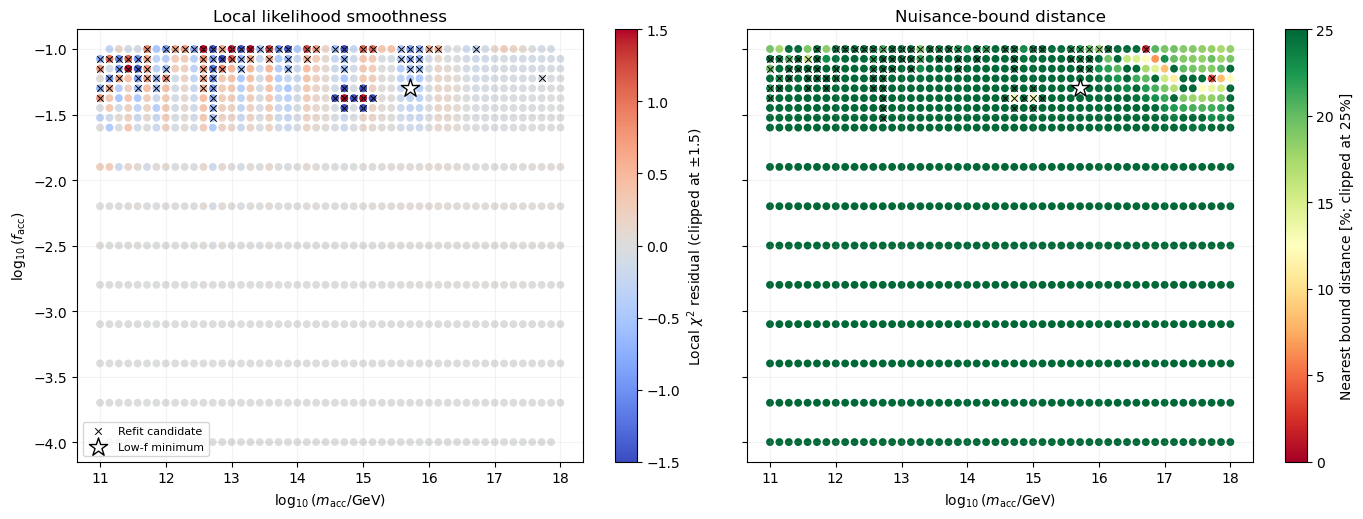

In [23]:
fig_fit, axes = plt.subplots(1, 2, figsize=(14.0, 5.3), sharex=True, sharey=True)
rough = axes[0].scatter(
    completed['log10m_acc'], completed['log10f_acc'],
    c=np.clip(completed['local_chi2_roughness'], -1.5, 1.5),
    cmap='coolwarm', vmin=-1.5, vmax=1.5, s=32, edgecolor='none',
)
fig_fit.colorbar(rough, ax=axes[0], label=r'Local $\chi^2$ residual (clipped at $\pm1.5$)')
axes[0].set_title('Local likelihood smoothness')

distance = 100 * completed['minimum_bound_distance'].astype(float)
bounds = axes[1].scatter(
    completed['log10m_acc'], completed['log10f_acc'],
    c=np.clip(distance, 0, 25), cmap='RdYlGn', vmin=0, vmax=25,
    s=32, edgecolor='none',
)
fig_fit.colorbar(bounds, ax=axes[1], label='Nearest bound distance [%; clipped at 25%]')
axes[1].set_title('Nuisance-bound distance')
for ax in axes:
    ax.scatter(
        refit_candidates['log10m_acc'], refit_candidates['log10f_acc'],
        marker='x', s=22, color='black', linewidth=0.7, label='Refit candidate',
    )
    ax.scatter(
        [best['log10m_acc']], [best['log10f_acc']], marker='*', s=190,
        color='white', edgecolor='black', zorder=6, label='Low-f minimum',
    )
    ax.set_xlabel(r'$\log_{10}(m_{\rm acc}/\mathrm{GeV})$')
    ax.grid(alpha=0.15)
axes[0].set_ylabel(r'$\log_{10}(f_{\rm acc})$')
axes[0].legend(frameon=True, fontsize=8)
fig_fit.tight_layout()
plt.show()

## Save analysis products

In [24]:
if SAVE_OUTPUTS:
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
    completed.sort_values(['log10f_acc', 'log10m_acc']).to_csv(
        OUTPUT_DIR / 'lowf_merged_profile_likelihood.csv', index=False
    )
    overlap_chi2.to_csv(OUTPUT_DIR / 'momentum_resolution_overlaps.csv', index=False)
    nuisance_audit.to_csv(OUTPUT_DIR / 'nuisance_boundary_diagnostics.csv', index=False)
    boundary_summary.to_csv(OUTPUT_DIR / 'nuisance_boundary_summary.csv')
    allowed_warnings.to_csv(OUTPUT_DIR / 'nuisance_warnings_inside_lowf_95pct.csv', index=False)
    refit_candidates.to_csv(OUTPUT_DIR / 'targeted_refit_candidates.csv', index=False)
    best_summary = {
        'scope': 'provisional_low_fraction_slice',
        'point_id': best['point_id'],
        'log10m_acc': float(best['log10m_acc']),
        'log10f_acc': float(best['log10f_acc']),
        'f_acc': float(10**best['log10f_acc']),
        'momentum_bins': int(best['momentum_bins']),
        'chi2_one_loop': float(best['chi2_one_loop']),
        'lcdm_reference_chi2': LCDM_ONE_LOOP_CHI2,
        'delta_chi2_vs_lcdm': float(best['delta_chi2_vs_lcdm']),
        'best_point_on_highf_interface': bool(best_on_highf_interface),
        'lcdm_like_edge_chi2_spread': edge_spread,
        'maximum_overlap_abs_delta_chi2': maximum_overlap_shift,
        'minimum_nuisance_bound_distance': float(best['minimum_bound_distance']),
        'any_best_fit_nuisance_within_5pct': bool(best['near_bound_5pct']),
        'targeted_refit_candidate_count': int(len(refit_candidates)),
        'provisional_reasons': [
            'mixed_q1001_q2501_theory_resolution',
            'high_fraction_q5001_campaign_not_merged',
            'targeted_neighbor_refits_not_yet_completed',
        ],
    }
    (OUTPUT_DIR / 'lowf_best_fit_summary.json').write_text(
        json.dumps(best_summary, indent=2, sort_keys=True) + '\n',
        encoding='utf-8',
    )
    fig_sampled.savefig(OUTPUT_DIR / 'sampled_likelihood_and_q_source.png', dpi=220, bbox_inches='tight')
    fig_maps.savefig(OUTPUT_DIR / 'lowf_profile_likelihood_maps.png', dpi=220, bbox_inches='tight')
    fig_edge.savefig(OUTPUT_DIR / 'resolution_and_lcdm_edge_diagnostics.png', dpi=220, bbox_inches='tight')
    fig_fit.savefig(OUTPUT_DIR / 'fit_stability_diagnostics.png', dpi=220, bbox_inches='tight')
    print('Saved analysis products to:', OUTPUT_DIR)

Saved analysis products to: /home/2/ks405818/Master/lyalpha_one_loop/runs/accdm/analysis_lowf_q1001_q2501_v1


## Interpretation checklist

1. Quote the discrete low-fraction minimum, not the interpolated minimum.
2. If the minimum lies at `log10f_acc=-1`, wait for the q=5001 high-fraction campaign before calling it the accDM best fit.
3. Treat islands or contour displacements comparable to the measured q-overlap Delta chi2 as numerical, not physical.
4. Refit priority points from `targeted_refit_candidates.csv` using neighboring minima; start with candidates inside the conditional low-f 95% region.
5. A nuisance-bound warning is a numerical-box diagnostic, not a physical prior.
6. Validate final best-fit and contour anchors at q=5001 or q=10001 before publishing the combined map.